### Model 2: Traffic Accident Severity — Deep Neural Network

- Same prediction task as Model 1, but using a deep learning approach
- The same class imbalance challenge applies — evaluate with weighted F1
- Build a neural network (TensorFlow/Keras) on the tabular accident data
- Compare performance against your traditional ML model
- **Minimum Benchmark:** Accuracy > 70%, weighted F1 > 0.55
- **Stretch Goal:** Accuracy > 82%, weighted F1 > 0.72
- **Required:** Show how DNN performance compares to traditional ML and explain the trade-offs

Build Deep Learning Model using Google Colab due to GPU limit on local machine

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

# Model saving
import os
import joblib

# Settings
plt.style.use('seaborn-v0_8-whitegrid')

pd.set_option('display.max_columns', None)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')
#df = pd.read_csv('/content/drive/MyDrive/cleaned_data/cleaned_data.csv')
print(f"Data shape: {df.shape}")
df.head()

Data shape: (499290, 257)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Target,hour,day_of_week,month,is_weekend,is_morning_rush,is_evening_rush,is_rush_hour,duration_min,is_freezing,low_visibility,lat_bin,n_road_features,has_traffic_control,State_al,State_ar,State_az,State_ca,State_co,State_ct,State_dc,State_de,State_fl,State_ga,State_ia,State_id,State_il,State_in,State_ks,State_ky,State_la,State_ma,State_md,State_me,State_mi,State_mn,State_mo,State_ms,State_mt,State_nc,State_nd,State_ne,State_nh,State_nj,State_nm,State_nv,State_ny,State_oh,State_ok,State_or,State_pa,State_ri,State_sc,State_sd,State_tn,State_tx,State_ut,State_va,State_vt,State_wa,State_wi,State_wv,State_wy,State_nan,Timezone_missing,Timezone_us/central,Timezone_us/eastern,Timezone_us/mountain,Timezone_us/pacific,Timezone_nan,Wind_Direction_calm,Wind_Direction_e,Wind_Direction_east,Wind_Direction_ene,Wind_Direction_ese,Wind_Direction_missing,Wind_Direction_n,Wind_Direction_ne,Wind_Direction_nne,Wind_Direction_nnw,Wind_Direction_north,Wind_Direction_nw,Wind_Direction_s,Wind_Direction_se,Wind_Direction_south,Wind_Direction_sse,Wind_Direction_ssw,Wind_Direction_sw,Wind_Direction_var,Wind_Direction_variable,Wind_Direction_w,Wind_Direction_west,Wind_Direction_wnw,Wind_Direction_wsw,Wind_Direction_nan,Weather_Condition_blowing dust,Weather_Condition_blowing dust / windy,Weather_Condition_blowing snow,Weather_Condition_blowing snow / windy,Weather_Condition_clear,Weather_Condition_cloudy,Weather_Condition_cloudy / windy,Weather_Condition_drifting snow / windy,Weather_Condition_drizzle,Weather_Condition_drizzle / windy,Weather_Condition_drizzle and fog,Weather_Condition_duststorm,Weather_Condition_fair,Weather_Condition_fair / windy,Weather_Condition_fog,Weather_Condition_fog / windy,Weather_Condition_freezing drizzle,Weather_Condition_freezing rain,Weather_Condition_hail,Weather_Condition_haze,Weather_Condition_haze / windy,Weather_Condition_heavy drizzle,Weather_Condition_heavy freezing drizzle,Weather_Condition_heavy rain,Weather_Condition_heavy rain / windy,Weather_Condition_heavy sleet,Weather_Condition_heavy snow,Weather_Condition_heavy snow / windy,Weather_Condition_heavy t-storm,Weather_Condition_heavy t-storm / windy,Weather_Condition_heavy thunderstorms and rain,Weather_Condition_ice pellets,Weather_Condition_light drizzle,Weather_Condition_light drizzle / windy,Weather_Condition_light freezing drizzle,Weather_Condition_light freezing fog,Weather_Condition_light freezing rain,Weather_Condition_light freezing rain / windy,Weather_Condition_light ice pellets,Weather_Condition_light rain,Weather_Condition_light rain / windy,Weather_Condition_light rain shower,Weather_Condition_light rain shower / windy,Weather_Condition_light rain showers,Weather_Condition_light rain with thunder,Weather_Condition_light sleet,Weather_Condition_light sleet / windy,Weather_Condition_light snow,Weather_Condition_light snow / windy,Weather_Condition_light snow and sleet,Weather_Condition_light snow and sleet / windy,Weather_Condition_light snow grains,Weather_Condition_light snow shower,Weather_Condition_light snow showers,Weather_Condition_light snow with thunder,Weather_Condition_light thunderstorms and rain,Weather_Condition_light thunderstorms and snow,Weather_Condition_missing,Weather_Condition_mist,Weather_Condition_mist / windy,Weather_Condition_mostly cloudy,Weather_Condition_mostly cloudy / windy,Weather_Condition_n/a precipitation,Weather_Condition_overcast,Weather_Condition_partial fog,Weather_Condition_partly cloudy,Weather_Condition_partly cloudy / windy,Weather_Condition_patches of fog,Weather_Condition_patches of fog / windy,Weather_Condition_rain,Weather_Condition_rain / windy,Weather_Condition_rain shower,Wea

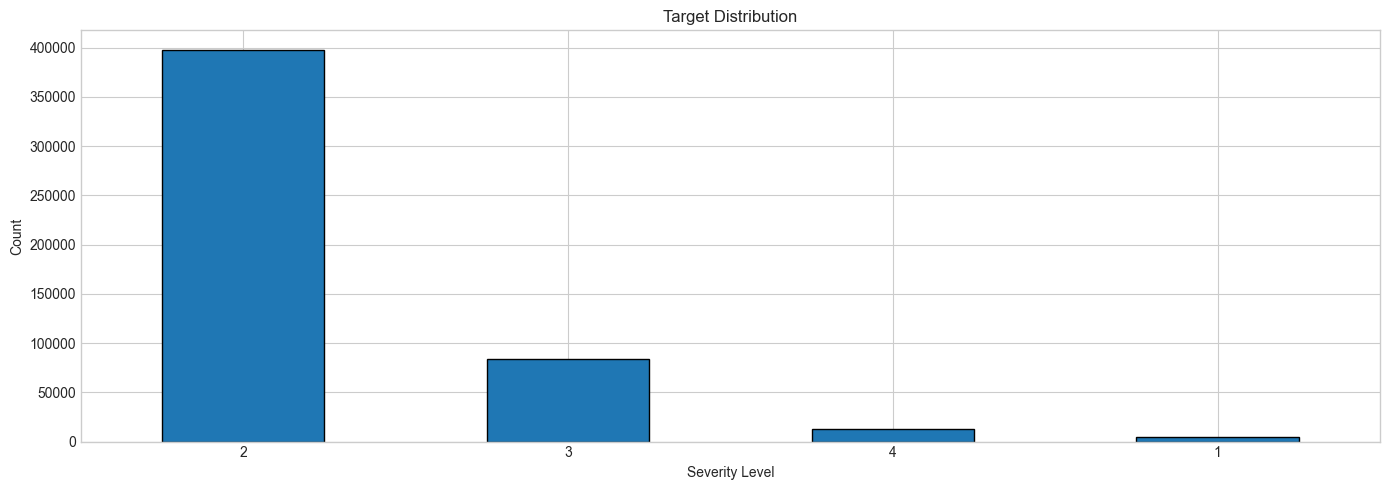

In [5]:
# Visualize the binned distribution
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Binned category counts
df['Target'].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [6]:
# Check class balance
class_counts = df['Target'].value_counts()
class_percentages = df['Target'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
2: 397669 (79.6%)
3: 84039 (16.8%)
4: 13229 (2.6%)
1: 4353 (0.9%)

Consider adjusting your binning strategy.


In [7]:
X = df.drop(columns=['Severity', 'Target', 'Start_Time', 'End_Time', 'Weather_Timestamp']).copy()
y = df['Target']

In [8]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (499290, 252)
Target shape: (499290,)

Features used: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'City', 'County', 'Airport_Code', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'duration_min', 'is_freezing', 'low_visibility', 'lat_bin', 'n_road_features', 'has_traffic_control', 'State_al', 'State_ar', 'State_az', 'State_ca', 'State_co', 'State_ct', 'State_dc', 'State_de', 'State_fl', 'State_ga', 'State_ia', 'State_id', 'State_il', 'State_in', 'State_ks', 'State_ky', 'State_la', 'State_ma', 'State_md', 'State_me', 'State_mi', 'State_mn', 'State_mo', 'State_ms', 'State_mt', 'State_nc', 'State_nd', 'State_ne', 'State_nh', 'State_nj', 'Sta

In [9]:
# -----------------------------
# 1. Split data
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 2. Scale numeric features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print("Original classes:", label_encoder.classes_)
print("Encoded train classes:", np.unique(y_train_enc))
print("Encoded test classes:", np.unique(y_test_enc))

Original classes: [1 2 3 4]
Encoded train classes: [0 1 2 3]
Encoded test classes: [0 1 2 3]


In [31]:
'''
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_enc)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights = dict(zip(classes, weights))
print("Class weights:")
for k,v in class_weights.items():
    print(f"{k}: {v:.2f}")
    '''

# Above fully balanced class weights improved Recall scores for level 3 and level 4 incidents.
# But it is dragging down overall accuracy due to level 2 is the majority class
# use a manual class weight to re-train the model

class_weights = {
    0: 2.0,   # class 1
    1: 1.0,   # class 2
    2: 1.5,   # class 3
    3: 3.0    # class 4
}


In [32]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f" {c} ({c/len(y_train)*100:.1f}%)")

Training set: 399432 samples
Test set: 99858 samples

Training class distribution:
 3483 (0.9%)
 318135 (79.6%)
 67231 (16.8%)
 10583 (2.6%)


In [33]:
SELECTED_FEATURES = X.columns.tolist()
print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 252 features.


In [34]:
from tensorflow import keras
from tensorflow.keras import layers

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.backend.clear_session()

nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(4, activation="softmax")
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [36]:
history = nn_model.fit(
    X_train_scaled,
    y_train_enc,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7641 - loss: 0.9129 - val_accuracy: 0.7998 - val_loss: 0.5463
Epoch 2/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7933 - loss: 0.7887 - val_accuracy: 0.8032 - val_loss: 0.5190
Epoch 3/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7958 - loss: 0.7577 - val_accuracy: 0.8097 - val_loss: 0.5048
Epoch 4/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7986 - loss: 0.7365 - val_accuracy: 0.8102 - val_loss: 0.4978
Epoch 5/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8009 - loss: 0.7222 - val_accuracy: 0.8141 - val_loss: 0.4869
Epoch 6/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8034 - loss: 0.7083 - val_accuracy: 0.8151 - val_loss: 0.4794
Epoch 7/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8055 - loss: 0.6981 - val_accuracy: 0.8186 - val_loss: 0.4697
Epoch 8/100
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8067 - 

In [37]:
def plot_training_curves(history):
    """
    Plot training and validation loss/accuracy curves.

    Creates two side-by-side subplots:
    - Left: Training vs Validation Loss
    - Right: Training vs Validation Accuracy

    Args:
        history: Keras training history object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

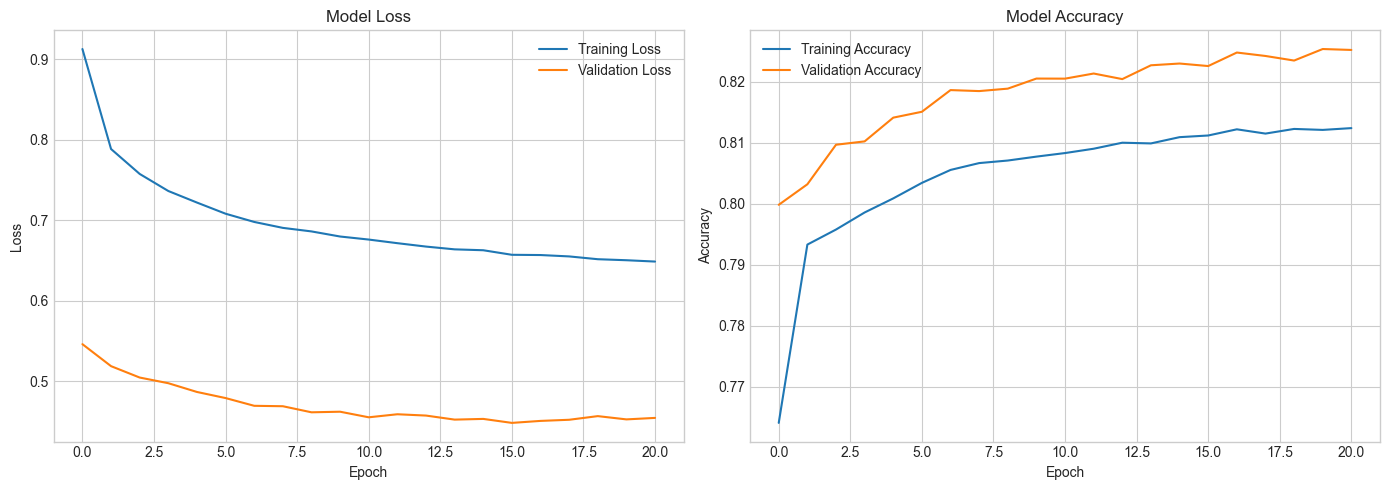

In [39]:
plot_training_curves(history)

In [40]:
y_train_pred_proba = nn_model.predict(X_train_scaled)

p0 = y_train_pred_proba[:, 0]   # class 1
p1 = y_train_pred_proba[:, 1]   # class 2
p2 = y_train_pred_proba[:, 2]   # class 3
p3 = y_train_pred_proba[:, 3]   # class 4

y_train_pred_adj = []

for i in range(len(y_train_pred_proba)):
    # favor class 1 if probability clears a lower custom threshold
    if p0[i] >= 0.30:
        y_train_pred_adj.append(0)
    # favor class 4 if strong enough
    elif p3[i] >= 0.40:
        y_train_pred_adj.append(3)
    else:
        y_train_pred_adj.append(np.argmax(y_train_pred_proba[i]))

y_train_pred_adj = np.array(y_train_pred_adj)

12483/12483 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step


In [41]:
y_pred_proba = nn_model.predict(X_test_scaled)

p0 = y_pred_proba[:, 0]   # class 1
p1 = y_pred_proba[:, 1]   # class 2
p2 = y_pred_proba[:, 2]   # class 3
p3 = y_pred_proba[:, 3]   # class 4

y_pred_adj = []

for i in range(len(y_pred_proba)):
    # favor class 1 if probability clears a lower custom threshold
    if p0[i] >= 0.30:
        y_pred_adj.append(0)
    # favor class 4 if strong enough
    elif p3[i] >= 0.20:
        y_pred_adj.append(3)
    else:
        y_pred_adj.append(np.argmax(y_pred_proba[i]))

y_pred_adj = np.array(y_pred_adj)

3121/3121 ━━━━━━━━━━━━━━━━━━━━ 3s 978us/step


In [42]:
y_train_pred = y_train_pred_adj
y_test_pred = y_pred_adj

In [43]:
print (f"'Train Accuracy': {accuracy_score(y_train_enc, y_train_pred):.4f}")

'Train Accuracy': 0.8242


In [44]:
print (f"'Test Accuracy': {accuracy_score(y_test_enc, y_test_pred):.4f}")

'Test Accuracy': 0.7979


In [45]:
print (f"'Precision (weighted)': {precision_score(y_test_enc, y_test_pred, average='weighted'):.4f}")

'Precision (weighted)': 0.8072


In [46]:
print (f"'Recall (weighted)': {recall_score(y_test_enc, y_test_pred, average='weighted'):.4f}")

'Recall (weighted)': 0.7979


In [47]:
print (f"'F1 (weighted)': {f1_score(y_test_enc, y_test_pred, average='weighted'):.4f}")

'F1 (weighted)': 0.7961


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_enc, y_pred_adj, target_names=["1", "2", "3", "4"]))
print(confusion_matrix(y_test_enc, y_pred_adj))

              precision    recall  f1-score   support

           1       1.00      0.00      0.01       870
           2       0.87      0.89      0.88     79534
           3       0.59      0.47      0.52     16808
           4       0.22      0.45      0.30      2646

    accuracy                           0.80     99858
   macro avg       0.67      0.45      0.43     99858
weighted avg       0.81      0.80      0.80     99858

[[    3   802    62     3]
 [    0 70585  5360  3589]
 [    0  8323  7899   586]
 [    0  1312   143  1191]]


Below is the classification report and confusion matrics of the traditional ML model performance

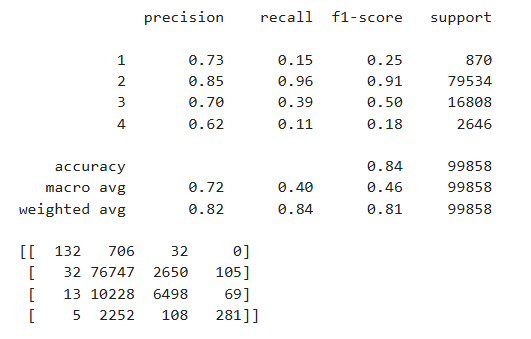

We built a deep learning neural network multi-class classification model with emphasis on better at predicting level 3 and level 4 accidents.
Comparing Tradiotional ML (XGBoost) model to the Deep Learning model we just built and trained:


# ***Overall performance***
________________________________________
XGBoost (Traditional ML)

*   Accuracy	0.84
*   Weighted F1	0.81

DNN (Keras)

*   Accuracy	0.80
*   Weighted 0.80

**Conclusion:**

Similar overall performance.
XGBoost has a slight edge in accuracy



***Class-level performance***
________________________________________


Class 1 (level 1 severity accidents, 870 rows)

XGBoost --- Recall 0.15 / Precision 0.73

DNN --- Recall 0.00 / Precision 1.00

**Conclusion:**

XGBoost is clearly better.
DNN almost misses class 1 entirely
________________________________________

Class 2 (level 2 severity accidents, 79k rows)

XGBoost --- Recall 0.96 / Precision 0.85

DNN --- Recall 0.89 / Precision 0.87


**Conclusion:**
XGBoost had better recall. DNN had slightly better precision

________________________________________

Class 3 (level 3 severity accidents, 16k rows)

XGBoost --- Recall 0.39 / F1 0.50

DNN --- Recall 0.47 / F1 0.52


**Conclusion:**
DNN wins here. It had better balance between precision & recall

________________________________________

Class 4 (level 4 severity accidents, 2.6k rows)

XGBoost --- Recall 0.11 / F1 0.18

DNN --- Recall 0.45 / F1 0.30


**Conclusion:**
DNN wins here. It had much improved recall and weighted F1 than traditional ML model 

________________________________________
***Insights and Trade-Offs***

XGBoost provides stronger baseline for tabular data - Higher accuracy with more stable decision boundaries


DNN is better at capturing complex patterns. It improved performance on class 3 and class 4. It learns nonlinear interactions across many features (we used 255 features)


**Trade-off is very clear**

XGBoost	has better accuracy and minority precision but misses some mid/rare signals

DNN	is better at minority detection (3 & 4)	but struggles with extreme imbalance (class 1)

Therefore:
If the goal is to achieve highest accuracy then use XGBoost
If the goal is to perform better at minority detection then use DNN


In [49]:
#saving this nn_model

model_path = "../models/model2_deep_learning/nn_model.h5"

# Create folder if not exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model
nn_model.save(model_path)

print(f"Model saved to {model_path}")

Model saved to ../models/model2_deep_learning/nn_model.h5
